# YOLO로 동물만 탐지

In [1]:
# YOLOv8 설치
!pip install -q ultralytics

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# YOLO로 신호등만 탐지


image 1/1 /content/신호등3.jpg: 352x640 1 traffic light, 320.2ms
Speed: 15.1ms preprocess, 320.2ms inference, 42.7ms postprocess per image at shape (1, 3, 352, 640)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

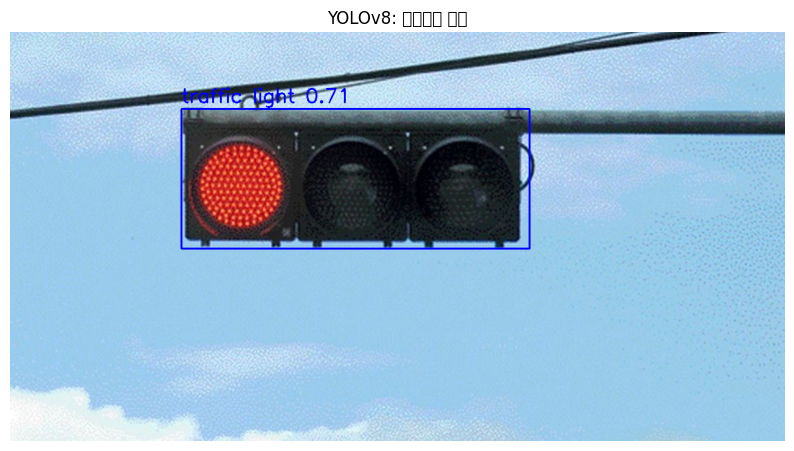

In [3]:
model = YOLO('yolov8n.pt')  # 가장 가벼운 버전
# 모델 로드 (이전 셀에서 설치 및 model 객체 재활용 가능)
results = model('/content/신호등3.jpg')

# 신호등(traffic light)만 필터링해서 시각화
img = cv2.imread('/content/신호등3.jpg')
for r in results:
    for box, label, conf in zip(r.boxes.xyxy.cpu().numpy(), r.boxes.cls.cpu().numpy(), r.boxes.conf.cpu().numpy()):
        name = model.names[int(label)]
        if name == 'traffic light':
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255,0,0), 2)
            cv2.putText(img, f'{name} {conf:.2f}', (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)
plt.figure(figsize=(10,7))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('YOLOv8: 신호등만 탐지')
plt.show()


# 사물 분리(Instance Segmentation)

--2026-06-14 23:44:50--  https://ultralytics.com/images/bus.jpg
Resolving ultralytics.com (ultralytics.com)... 216.150.1.1
Connecting to ultralytics.com (ultralytics.com)|216.150.1.1|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: https://www.ultralytics.com/images/bus.jpg [following]
--2026-06-14 23:44:50--  https://www.ultralytics.com/images/bus.jpg
Resolving www.ultralytics.com (www.ultralytics.com)... 216.150.1.1, 216.150.16.1
Connecting to www.ultralytics.com (www.ultralytics.com)|216.150.1.1|:443... connected.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg [following]
--2026-06-14 23:44:51--  https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: ht

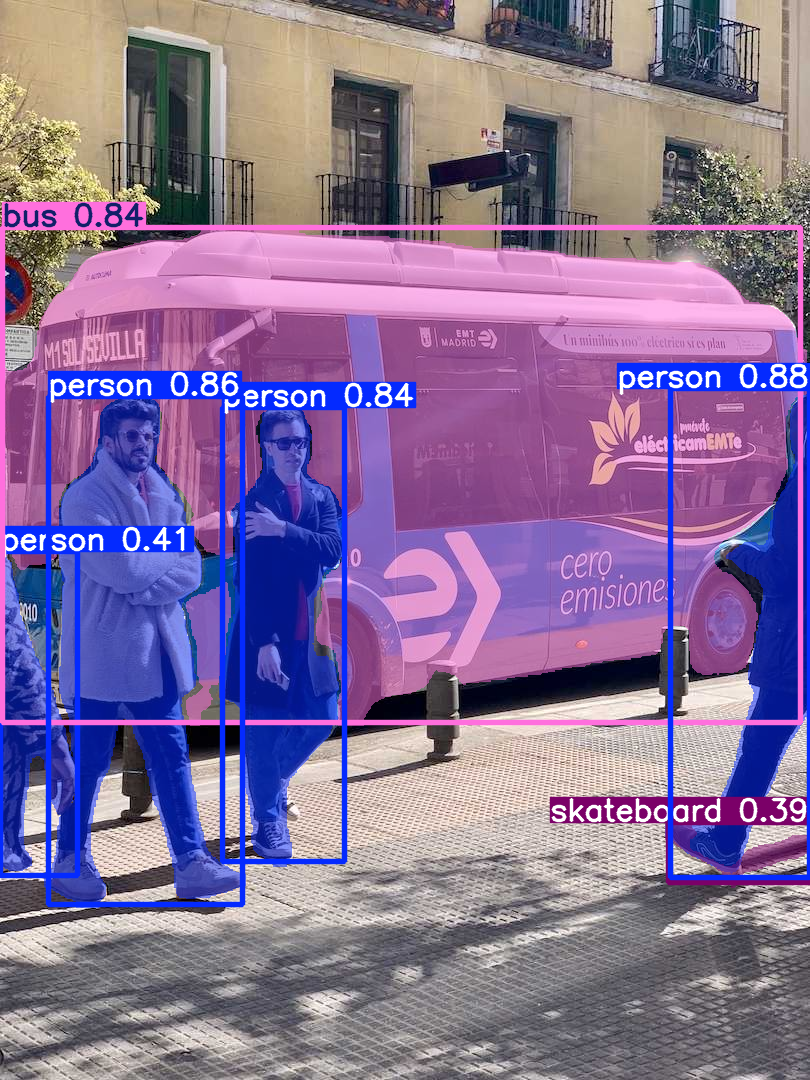

In [4]:


# 샘플 이미지 다운로드
!wget -O objects.jpg https://ultralytics.com/images/bus.jpg

# seg 모델 불러오기
seg_model = YOLO('yolov8n-seg.pt')  # YOLOv8의 세그먼트 전용 가중치 사용
results = seg_model('objects.jpg')

# 자동 시각화
# results.show()  # Segmentation 마스크까지 같이 보여줌 - This was the original line with the error
results[0].show() # Access the first element of the results list and call show()